Using Colab cache for faster access to the 'email-spam-detection-dataset-classification' dataset.
Path to dataset files: /kaggle/input/email-spam-detection-dataset-classification
csv файл: /kaggle/input/email-spam-detection-dataset-classification/spam.csv
  category                                            message
0      ham  Go until jurong point, crazy.. Available only ...
1      ham                      Ok lar... Joking wif u oni...
2     spam  Free entry in 2 a wkly comp to win FA Cup fina...
3      ham  U dun say so early hor... U c already then say...
4      ham  Nah I don't think he goes to usf, he lives aro...
(5572, 2)
category
ham     4825
spam     747
Name: count, dtype: int64
Train: 4457
Validation: 1115


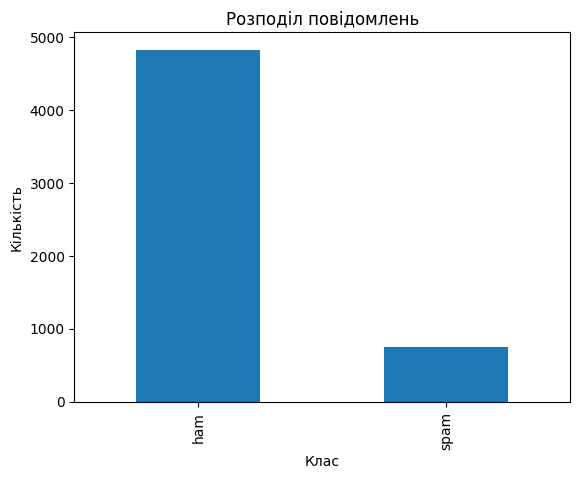

In [2]:
import os
import re
import kagglehub
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix


#завантажуємо датасет
path = kagglehub.dataset_download('shantanudhakadd/email-spam-detection-dataset-classification')

print('Path to dataset files:', path)


#знаходимо csv файл
csv_file = ''

for root, dirs, files in os.walk(path):
    for file in files:
        if file.endswith('.csv'):
            csv_file = os.path.join(root, file)
            break
    if csv_file != '':
        break

print('csv файл:', csv_file)


#зчитуємо дані
df = pd.read_csv(csv_file, encoding='latin-1')

df = df.iloc[:, :2]
df.columns = ['category', 'message']

print(df.head())
print(df.shape)
print(df['category'].value_counts())


#очищаємо текст
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()


df['message'] = df['message'].apply(clean_text)
df['label'] = df['category'].map({'ham': 0, 'spam': 1})


#розділяємо дані
X = df['message']
y = df['label']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print('Train:', len(X_train))
print('Validation:', len(X_val))


#показуємо розподіл класів
df['category'].value_counts().plot(kind='bar')
plt.title('Розподіл повідомлень')
plt.xlabel('Клас')
plt.ylabel('Кількість')
plt.show()

In [3]:
#BoW
bow = CountVectorizer(max_features=5000, ngram_range=(1, 2))

X_train_bow = bow.fit_transform(X_train)
X_val_bow = bow.transform(X_val)

print('BoW:', X_train_bow.shape)


model_bow = LogisticRegression(max_iter=1000)

model_bow.fit(X_train_bow, y_train)

pred_bow = model_bow.predict(X_val_bow)
prob_bow = model_bow.predict_proba(X_val_bow)[:, 1]

accuracy_bow = accuracy_score(y_val, pred_bow)
auc_bow = roc_auc_score(y_val, prob_bow)

print('BoW Accuracy:', accuracy_bow)
print('BoW AUC:', auc_bow)


#TF-IDF
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))

X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf = tfidf.transform(X_val)

print('TF-IDF:', X_train_tfidf.shape)


model_tfidf = LogisticRegression(max_iter=1000)

model_tfidf.fit(X_train_tfidf, y_train)

pred_tfidf = model_tfidf.predict(X_val_tfidf)
prob_tfidf = model_tfidf.predict_proba(X_val_tfidf)[:, 1]

accuracy_tfidf = accuracy_score(y_val, pred_tfidf)
auc_tfidf = roc_auc_score(y_val, prob_tfidf)

print('TF-IDF Accuracy:', accuracy_tfidf)
print('TF-IDF AUC:', auc_tfidf)

BoW: (4457, 5000)
BoW Accuracy: 0.9802690582959641
BoW AUC: 0.9863131713146303
TF-IDF: (4457, 5000)
TF-IDF Accuracy: 0.9704035874439462
TF-IDF AUC: 0.9897244570428113


In [4]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 51.6 MB/s eta 0:00:00:00:0100:01


[==================================================] 100.0% 66.0/66.0MB downloaded
GloVe: (4457, 50)
GloVe Accuracy: 0.9515695067264573
GloVe AUC: 0.9667521225005905
              precision    recall  f1-score   support

         ham       0.97      1.00      0.98       966
        spam       0.99      0.79      0.88       149

    accuracy                           0.97      1115
   macro avg       0.98      0.89      0.93      1115
weighted avg       0.97      0.97      0.97      1115



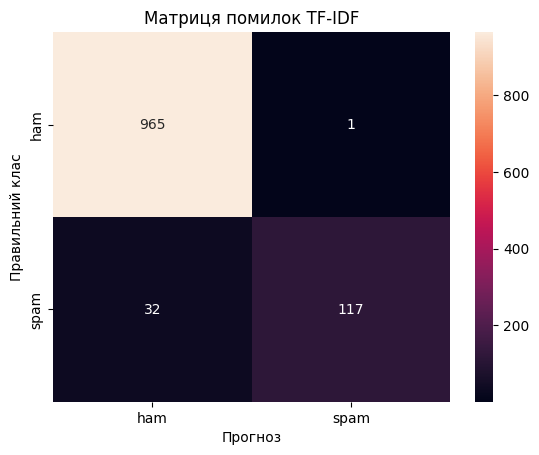

In [5]:
#завантажуємо GloVe
import gensim.downloader as api

glove = api.load('glove-wiki-gigaword-50')


#функція для перетворення тексту у вектор
def text_to_vector(text):
    words = text.split()
    vectors = []

    for word in words:
        if word in glove:
            vectors.append(glove[word])

    if len(vectors) == 0:
        return np.zeros(50)

    return np.mean(vectors, axis=0)


X_train_glove = np.array([text_to_vector(text) for text in X_train])
X_val_glove = np.array([text_to_vector(text) for text in X_val])

print('GloVe:', X_train_glove.shape)


#створюємо модель
model_glove = LogisticRegression(max_iter=1000)

model_glove.fit(X_train_glove, y_train)

pred_glove = model_glove.predict(X_val_glove)
prob_glove = model_glove.predict_proba(X_val_glove)[:, 1]

accuracy_glove = accuracy_score(y_val, pred_glove)
auc_glove = roc_auc_score(y_val, prob_glove)

print('GloVe Accuracy:', accuracy_glove)
print('GloVe AUC:', auc_glove)


#звіт для TF-IDF
print(classification_report(y_val, pred_tfidf, target_names=['ham', 'spam']))


#матриця помилок
cm = confusion_matrix(y_val, pred_tfidf)

sns.heatmap(cm, annot=True, fmt='d', xticklabels=['ham', 'spam'], yticklabels=['ham', 'spam'])

plt.xlabel('Прогноз')
plt.ylabel('Правильний клас')
plt.title('Матриця помилок TF-IDF')
plt.show()

    Model  Accuracy       AUC
0     BoW  0.980269  0.986313
1  TF-IDF  0.970404  0.989724
2   GloVe  0.951570  0.966752


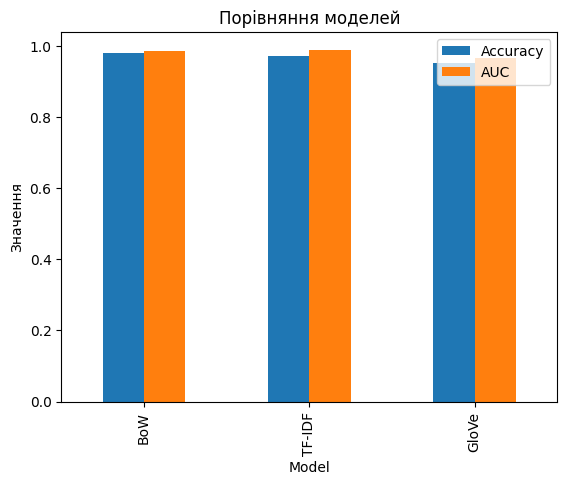

Найкраща модель: TF-IDF
Кількість помилок: 33
5       freemsg hey there darling it s been week s now...
1021    guess what somebody you know secretly fancies ...
3748    dear voucher holder claim your st class airpor...
855     talk sexy make new friends or fall in love in ...
3139    sexy sexy cum and text me im wet and warm and ...
1662    hi if ur lookin saucy daytime fun wiv busty ma...
1962    it to your free text messages are valid until ...
573                                 waiting for your call
3979                                         ringtoneking
3358    sorry i missed your call let s talk when you h...
Name: message, dtype: object


In [6]:
#порівнюємо результати
results = pd.DataFrame({
    'Model': ['BoW', 'TF-IDF', 'GloVe'],
    'Accuracy': [accuracy_bow, accuracy_tfidf, accuracy_glove],
    'AUC': [auc_bow, auc_tfidf, auc_glove]
})

print(results)


#графік результатів
results.plot(x='Model', y=['Accuracy', 'AUC'], kind='bar')

plt.title('Порівняння моделей')
plt.ylabel('Значення')
plt.show()


#знаходимо найкращу модель
best_model = results.loc[results['AUC'].idxmax(), 'Model']

print('Найкраща модель:', best_model)


#дивимось на помилки
errors = X_val[pred_tfidf != y_val]

print('Кількість помилок:', len(errors))

print(errors.head(10))